# Week 2: Data Preprocessing & Feature Engineering

## Customer Churn Prediction

### AnalystLab Africa Machine Learning Internship Programme

**Project:** Customer Churn Prediction  
**Company:** ABC Communications Ltd  
**Dataset:** Telco Customer Churn Dataset  
**Week:** 2  
**Focus:** Data Preprocessing & Feature Engineering

---

## 1. Introduction

Following the business understanding and exploratory data analysis completed in Week 1, this project focuses on preparing the Telco Customer Churn dataset for machine learning model development.

Real-world datasets often contain missing values, inconsistent data types, duplicate records, categorical variables, outliers, and irrelevant features. These issues must be identified and appropriately handled before a machine learning model is trained.

The objective of this notebook is to develop a robust data preprocessing and feature engineering workflow that transforms the raw customer churn dataset into a clean, structured, and machine-learning-ready dataset.

### Objectives

This notebook will:

- Inspect the raw dataset.
- Identify data quality issues.
- Handle missing values.
- Remove duplicate records where necessary.
- Correct data types.
- Engineer meaningful features.
- Encode categorical variables.
- Detect and assess outliers.
- Scale numerical features where appropriate.
- Select relevant features.
- Produce and save a machine-learning-ready dataset.

The preprocessing decisions made throughout this notebook will be justified based on the characteristics of the dataset and the customer churn prediction problem.

# 2. Environment Setup

The following Python libraries will be used throughout the preprocessing and feature engineering workflow.

In [1]:
# ============================================================
# 2. Environment Setup
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import VarianceThreshold

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Load Dataset

The project uses the same Telco Customer Churn dataset used during Week 1.

The dataset contains customer demographic information, service subscriptions, account information, billing details, and the customer's churn status.

The dataset will be loaded directly from the Kaggle environment.

In [2]:
# ============================================================
# 3. Load Dataset
# ============================================================

dataset_path = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [4]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


# 4. Initial Data Inspection

The dataset will now be inspected to understand its structure, dimensions, data types, and general characteristics.

This step helps identify potential data quality issues before preprocessing begins.

In [5]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [6]:
# Display column names
print("Dataset Columns:\n")

for column in df.columns:
    print(column)

Dataset Columns:

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [7]:
# Review data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 5.1 Descriptive Statistics

Descriptive statistics are used to understand the numerical characteristics of the dataset, including measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


# 6. Missing Value Assessment

Missing values can negatively affect machine learning models and must therefore be identified before model development.

The following analysis checks the number and percentage of missing values in each feature.

In [11]:

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

,Missing Values,Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


# 7. Duplicate Record Assessment

Duplicate records can introduce bias into a machine learning dataset because the same observation may be represented multiple times.

The dataset will therefore be checked for duplicate rows before preprocessing.

In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


### Observation

The number of duplicate records identified above will determine whether duplicate removal is necessary.

If duplicate records exist, they will be removed during the data cleaning stage. If no duplicates are found, no removal will be performed.

# 8. Data Type Investigation

The `TotalCharges` variable represents the total amount charged to a customer and should therefore be numerical.

Its current data type will be investigated and converted appropriately if necessary.

In [13]:
print("TotalCharges data type:", df["TotalCharges"].dtype)

TotalCharges data type: object


In [14]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

# 9. Investigation of TotalCharges

The `TotalCharges` feature represents the total amount charged to each customer. Although it is a numerical variable, it is currently stored as an object data type.

This may be caused by blank or non-numeric values in the original dataset.

Before converting the column to numeric, the values that cannot be interpreted as numbers will be identified and investigated.

In [15]:
# Identify values in TotalCharges that cannot be converted to numeric

total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = total_charges_numeric.isna().sum()

print("Number of non-numeric TotalCharges values:", invalid_total_charges)

Number of non-numeric TotalCharges values: 11


In [16]:
# Display records with invalid TotalCharges values

df.loc[total_charges_numeric.isna(), [
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


# 10. Data Type Correction

The `TotalCharges` column contains 11 blank values that cannot be interpreted as numerical values.

These records have a tenure of zero, meaning the customers have not yet accumulated any charges. The blank values will therefore be converted to missing numerical values (`NaN`) and subsequently treated using an appropriate imputation strategy.

The column will then be converted from object to a numerical data type.

In [17]:
# Convert TotalCharges to numeric.
# Invalid/blank values are converted to NaN.

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges data type after conversion:")
print(df["TotalCharges"].dtype)

TotalCharges data type after conversion:
float64


# 11. Missing Value Treatment

After converting `TotalCharges` to a numerical variable, 11 missing values were identified.

These values correspond to customers with zero tenure. Since `TotalCharges` represents the accumulated amount charged to a customer, replacing these values with zero is appropriate because customers with zero tenure have not accumulated any charges.

Therefore, the 11 missing `TotalCharges` values will be replaced with 0.

In [18]:
# Check the missing values created after converting TotalCharges

print("Missing TotalCharges before treatment:",
      df["TotalCharges"].isna().sum())

Missing TotalCharges before treatment: 11


In [19]:
# Replace missing TotalCharges values with 0

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges after treatment:",
      df["TotalCharges"].isna().sum())

Missing TotalCharges after treatment: 0


In [20]:
df["TotalCharges"].fillna(df["TotalCharges"].median())

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

# 12. Post-Cleaning Missing Value Check

After treating the missing `TotalCharges` values, the dataset will be checked again to confirm that no missing values remain.

In [21]:
missing_after_cleaning = df.isnull().sum()

missing_after_cleaning[
    missing_after_cleaning > 0
]

Series([], dtype: int64)

# 13. Duplicate Treatment

The initial dataset inspection identified zero duplicate records.

Therefore, no rows were removed on the basis of duplication. The original 7,043 customer records are retained.

In [22]:
# Confirm that there are still no duplicate records

print("Duplicate records:", df.duplicated().sum())
print("Current dataset shape:", df.shape)

Duplicate records: 0
Current dataset shape: (7043, 21)


# 14. Removing Irrelevant Features

The `customerID` column is a unique identifier assigned to each customer. It does not contain meaningful behavioral, demographic, service, or billing information that can help predict churn.

Therefore, `customerID` will be removed before model development.

This prevents the identifier from being unnecessarily encoded and used as a machine learning feature.

In [23]:
# Remove customerID because it is an identifier rather than a predictive feature

df = df.drop(columns=["customerID"])

print("customerID removed successfully.")
print("New dataset shape:", df.shape)

customerID removed successfully.
New dataset shape: (7043, 20)


# 15. Cleaned Dataset Overview

The dataset will now be inspected after the initial cleaning operations.

At this stage:

- `TotalCharges` has been converted to numeric.
- Missing `TotalCharges` values have been treated.
- No duplicate records were removed because none existed.
- `customerID` has been removed because it is an identifier.

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [26]:
df.isnull().sum().sum()

np.int64(0)

In [27]:
# Display unique values for categorical features

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn
['No' 'Yes']


# 16. Feature Engineering

Feature engineering involves creating meaningful variables from existing data to better represent customer behavior and improve the ability of machine learning models to identify customers at risk of churn.

For this project, new features will be created based on customer tenure, subscribed services, and billing behavior.

Each engineered feature is designed to have a potential business interpretation related to customer retention and churn.

## 16.1 Customer Tenure Group

Customer tenure is an important indicator of customer relationship length.

A categorical `tenure_group` feature will be created to classify customers into different stages of their relationship with the company. This may help the model capture differences between newer and long-term customers.

The groups are:

- 0–12 months: New
- 13–24 months: Developing
- 25–48 months: Established
- 49–72 months: Long-term

In [28]:
# Create customer tenure groups

def categorize_tenure(months):
    if months <= 12:
        return "New"
    elif months <= 24:
        return "Developing"
    elif months <= 48:
        return "Established"
    else:
        return "Long-term"


df["tenure_group"] = df["tenure"].apply(categorize_tenure)

# Display the result
df[["tenure", "tenure_group"]].head(10)

,tenure,tenure_group
0,1,New
1,34,Established
2,2,New
3,45,Established
4,2,New
5,8,New
6,22,Developing
7,10,New
8,28,Established
9,62,Long-term


In [29]:
df["tenure_group"].value_counts()

tenure_group
Long-term      2239
New            2186
Established    1594
Developing     1024
Name: count, dtype: int64

## 16.2 Total Number of Services

A `total_services` feature will be created to represent the number of services subscribed to by each customer.

The feature will count active services while treating values such as `No phone service` and `No internet service` as the absence of that particular service.

This feature provides a compact measure of customer engagement with the company's services.

In [30]:
# Define service-related columns

service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Count active services
df["total_services"] = 0

for column in service_columns:
    df["total_services"] += (
        ~df[column].isin(["No", "No phone service", "No internet service"])
    ).astype(int)

# Display results
df[service_columns + ["total_services"]].head(10)

,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,total_services
0,No,No phone service,DSL,No,Yes,No,No,No,No,2
1,Yes,No,DSL,Yes,No,Yes,No,No,No,4
2,Yes,No,DSL,Yes,Yes,No,No,No,No,4
3,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,4
4,Yes,No,Fiber optic,No,No,No,No,No,No,2
5,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,6
6,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,5
7,No,No phone service,DSL,Yes,No,No,No,No,No,2
8,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,7
9,Yes,No,DSL,Yes,Yes,No,No,No,No,4


In [31]:
df["total_services"].value_counts().sort_index()

total_services
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64

## 16.3 Feature Engineering Decision: Average Charges

An average charge based on `TotalCharges / tenure` was considered.

However, this feature would largely reproduce the information already represented by `MonthlyCharges`, since total charges are accumulated from monthly charges over the customer's tenure.

Therefore, this feature will not be included in the final dataset in order to avoid unnecessary redundancy and potential multicollinearity.

In [32]:
# Display the newly engineered features

df[
    [
        "tenure",
        "tenure_group",
        "total_services",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ]
].head(10)

,tenure,tenure_group,total_services,MonthlyCharges,TotalCharges,Churn
0,1,New,2,29.85,29.85,No
1,34,Established,4,56.95,1889.50,No
2,2,New,4,53.85,108.15,Yes
3,45,Established,4,42.30,1840.75,No
4,2,New,2,70.70,151.65,Yes
5,8,New,6,99.65,820.50,Yes
6,22,Developing,5,89.10,1949.40,No
7,10,New,2,29.75,301.90,No
8,28,Established,7,104.80,3046.05,Yes
9,62,Long-term,4,56.15,3487.95,No


## 16.5 Analysis of Engineered Features

The distributions of the newly created features will be examined to determine whether they provide meaningful variation across customers.

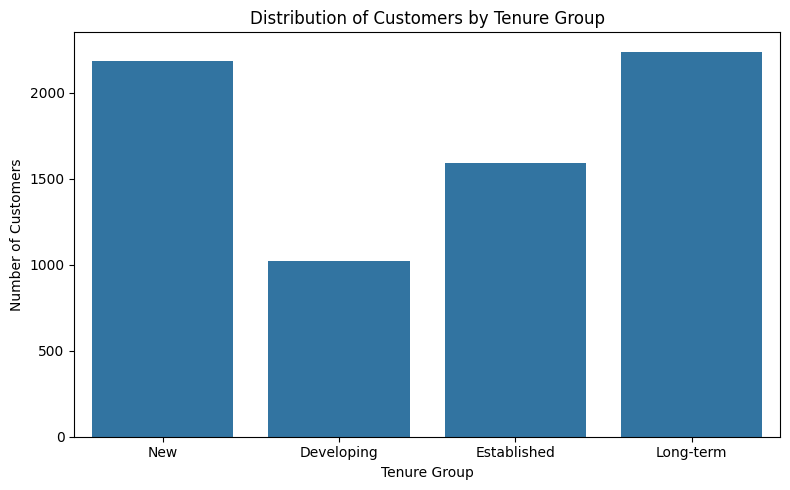

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="tenure_group",
    order=["New", "Developing", "Established", "Long-term"]
)

plt.title("Distribution of Customers by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

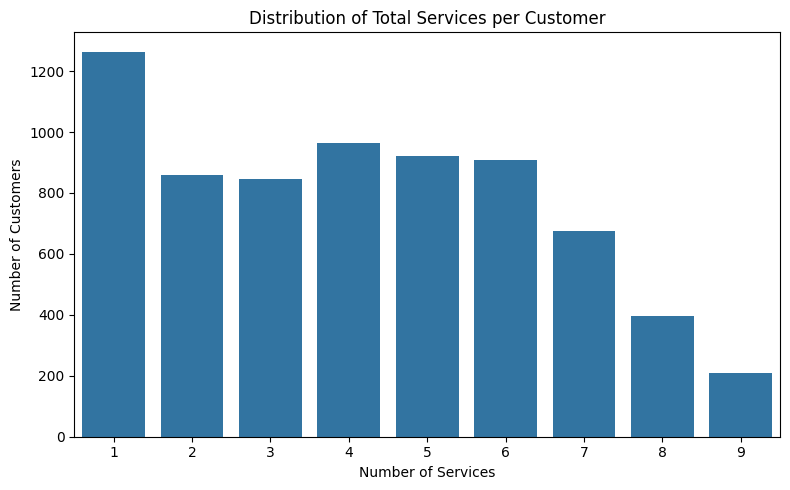

In [34]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="total_services"
)

plt.title("Distribution of Total Services per Customer")
plt.xlabel("Number of Services")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# 17. Relationship Between Engineered Features and Churn

The newly engineered features will be compared with the target variable, `Churn`, to assess whether they show meaningful differences between customers who churned and those who remained.

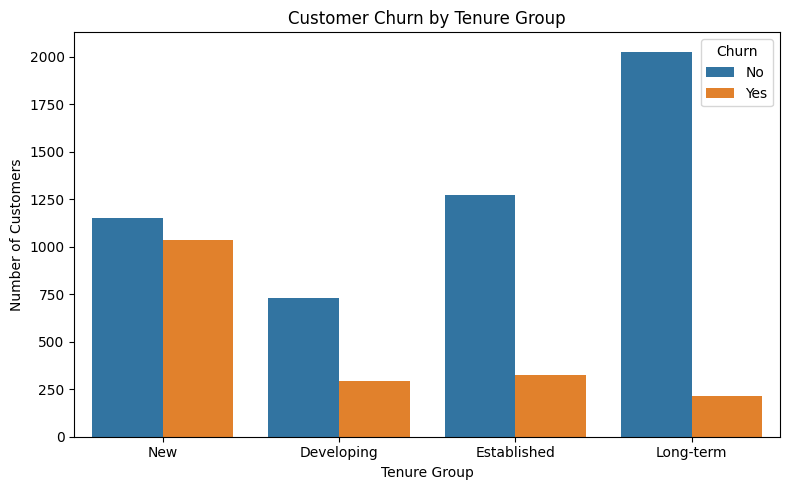

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="tenure_group",
    hue="Churn",
    order=["New", "Developing", "Established", "Long-term"]
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

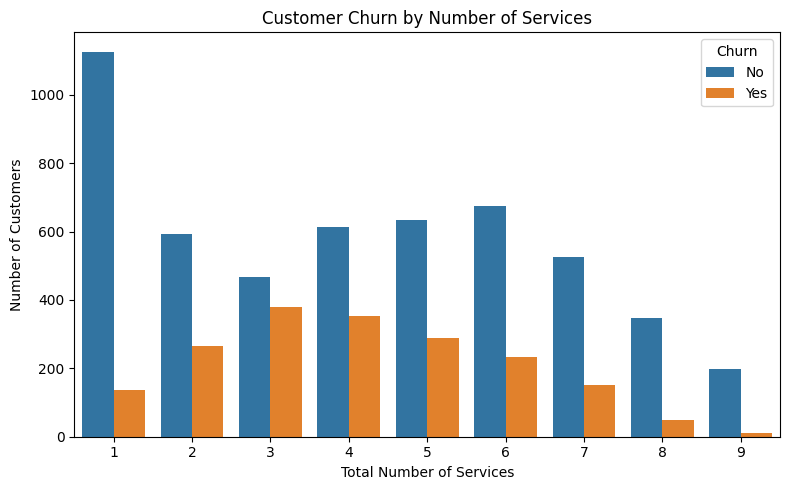

In [36]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="total_services",
    hue="Churn"
)

plt.title("Customer Churn by Number of Services")
plt.xlabel("Total Number of Services")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# 18. Feature Engineering Summary

Two meaningful features were created:

| Feature | Description | Business Reason |
|---|---|---|
| `tenure_group` | Groups customers according to relationship length | Helps identify differences between new and long-term customers |
| `total_services` | Counts the number of active services subscribed to | Represents customer engagement with the company's services |

The `customerID` feature was removed because it is an identifier and has no meaningful predictive value.

An average charge feature was considered but rejected because it would largely duplicate information already represented by `MonthlyCharges`.

In [37]:
df[["tenure", "tenure_group", "total_services", "Churn"]].head(10)

,tenure,tenure_group,total_services,Churn
0,1,New,2,No
1,34,Established,4,No
2,2,New,4,Yes
3,45,Established,4,No
4,2,New,2,Yes
5,8,New,6,Yes
6,22,Developing,5,No
7,10,New,2,No
8,28,Established,7,Yes
9,62,Long-term,4,No


# 19. Feature Encoding

Machine learning algorithms generally require numerical input. However, the dataset contains several categorical variables such as gender, contract type, internet service, and payment method.

These categorical variables must therefore be transformed into numerical representations.

For this project, One-Hot Encoding will be used for nominal categorical features. This approach creates separate binary columns for each category without imposing an artificial numerical ordering.

The target variable, `Churn`, will be encoded separately:

- No → 0
- Yes → 1

In [38]:
# ============================================================
# 19.1 Separate Target Variable
# ============================================================

# Convert Churn into a binary numerical target
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Target variable encoded successfully.")
print(df["Churn"].value_counts())

Target variable encoded successfully.
Churn
0    5174
1    1869
Name: count, dtype: int64


## 19.2 Identify Numerical and Categorical Features

The remaining predictor variables will be separated into numerical and categorical features.

Numerical variables will later be scaled, while categorical variables will be one-hot encoded.

In [39]:
# Define target
target = "Churn"

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

# Identify numerical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_services']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


## 19.3 Encoding Strategy

One-Hot Encoding is appropriate because most categorical variables in the dataset are nominal rather than naturally ordered.

For example, `PaymentMethod` contains:

- Electronic check
- Mailed check
- Bank transfer (automatic)
- Credit card (automatic)

There is no meaningful numerical ranking among these payment methods.

One-Hot Encoding represents each category as a separate binary feature and avoids introducing a false ordinal relationship.

# 20. Preprocessing Pipeline

A `ColumnTransformer` will be used to apply different preprocessing operations to numerical and categorical features.

The planned preprocessing strategy is:

### Numerical Features
- Imputation using the median where necessary.
- Standardization using `StandardScaler`.

### Categorical Features
- Imputation using the most frequent category where necessary.
- One-Hot Encoding.

Using a preprocessing pipeline ensures that the same transformations can later be consistently applied to training and unseen data.

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [41]:
# Number of unique categories in each categorical feature

category_counts = pd.DataFrame({
    "Feature": categorical_features,
    "Unique Categories": [
        X[column].nunique() for column in categorical_features
    ]
})

category_counts.sort_values(
    by="Unique Categories",
    ascending=False
)

,Feature,Unique Categories
15,tenure_group,4
14,PaymentMethod,4
7,OnlineBackup,3
6,OnlineSecurity,3
9,TechSupport,3
8,DeviceProtection,3
5,InternetService,3
4,MultipleLines,3
11,StreamingMovies,3
10,StreamingTV,3


# 22. Target Variable Distribution

The target variable will be examined to determine the proportion of customers who churned and those who remained.

This is important because a substantial imbalance between classes can influence model evaluation and may require the use of appropriate evaluation metrics.

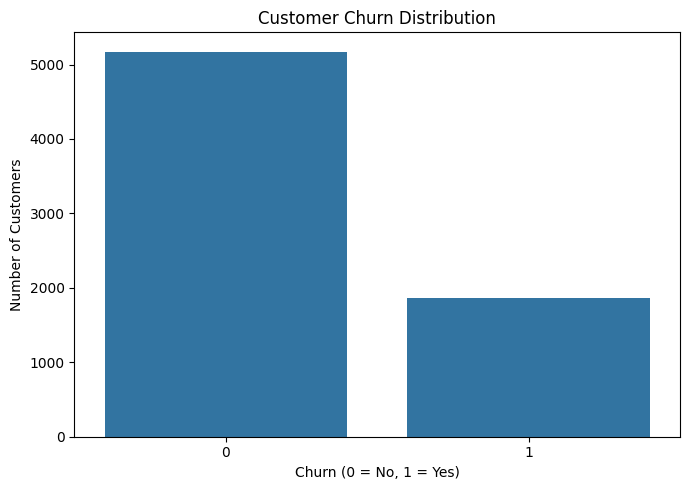

In [43]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [44]:
print("Target distribution:")
print(df["Churn"].value_counts())

print("\nTarget percentage:")
print(
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


# 23. Outlier Detection

Outliers are observations that are unusually large or small compared with the rest of the data.

In customer churn data, extreme values may represent genuine customer behavior rather than data errors. Therefore, outliers will first be detected and investigated before any treatment decision is made.

The numerical features considered for outlier analysis are:

- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges
- total_services

The `SeniorCitizen` variable is binary (0/1), so it is not a meaningful continuous variable for IQR-based outlier treatment. Therefore, the main analysis will focus on continuous numerical variables.

In [48]:
# Continuous numerical features for outlier analysis

continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "total_services"
]

print("Continuous features:")
print(continuous_features)

Continuous features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services']


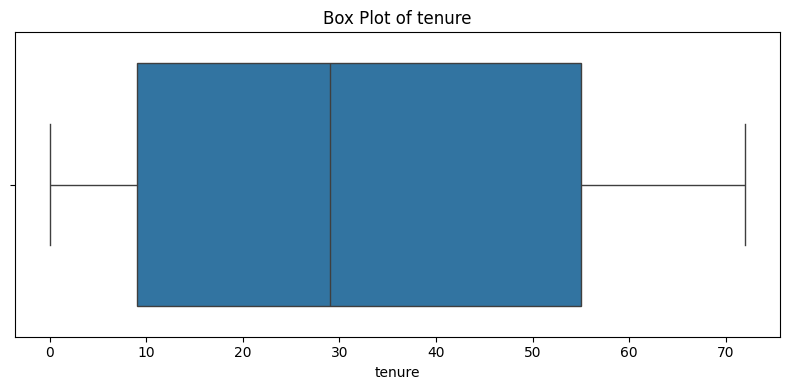

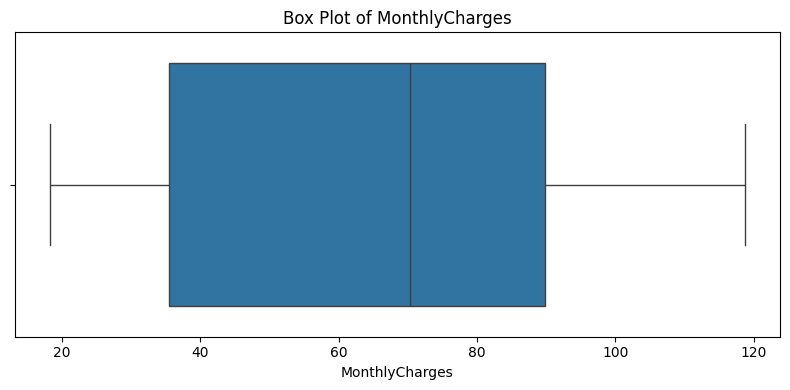

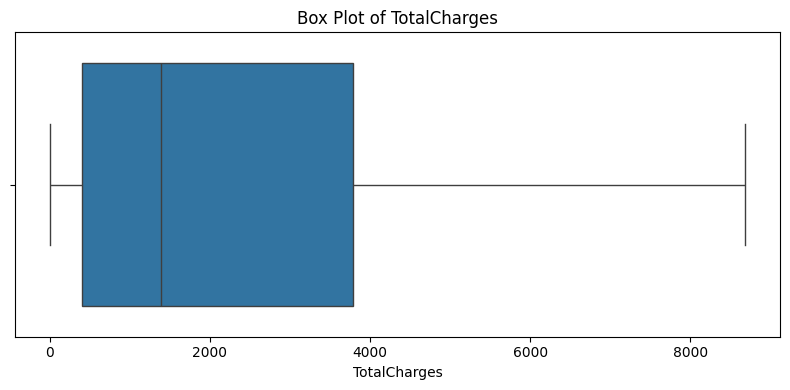

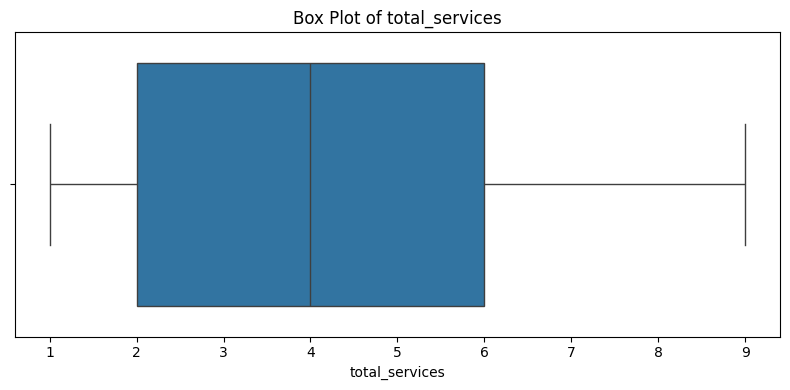

In [49]:
# ============================================================
# Box plots for continuous numerical features
# ============================================================

for column in continuous_features:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    
    plt.tight_layout()
    plt.show()

## 23.3 Interquartile Range (IQR) Method

The Interquartile Range method identifies potential outliers using the first quartile (Q1), third quartile (Q3), and the interquartile range (IQR).

Potential outliers are observations below the lower IQR boundary or above the upper IQR boundary.

The number of potential outliers will be calculated for each continuous numerical feature.

In [50]:
# ============================================================
# IQR Outlier Detection
# ============================================================

outlier_summary = []

for column in continuous_features:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(
            len(outliers) / len(df) * 100, 2
        )
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,tenure,9.00,55.00,46.00,-60.000,124.000,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.025,171.375,0,0.0
2,TotalCharges,398.55,3786.60,3388.05,-4683.525,8868.675,0,0.0
3,total_services,2.00,6.00,4.00,-4.000,12.000,0,0.0


## 23.4 Outlier Analysis Observation

The IQR analysis identified potential outliers in some continuous numerical features.

However, these observations are not automatically considered erroneous. In a telecommunications business context, customers with high monthly charges or high total charges can represent legitimate customers using premium services.

Therefore, the identified observations will not be automatically removed.

Instead, the preprocessing pipeline will retain legitimate customer observations and use appropriate scaling techniques to reduce the influence of different feature magnitudes.

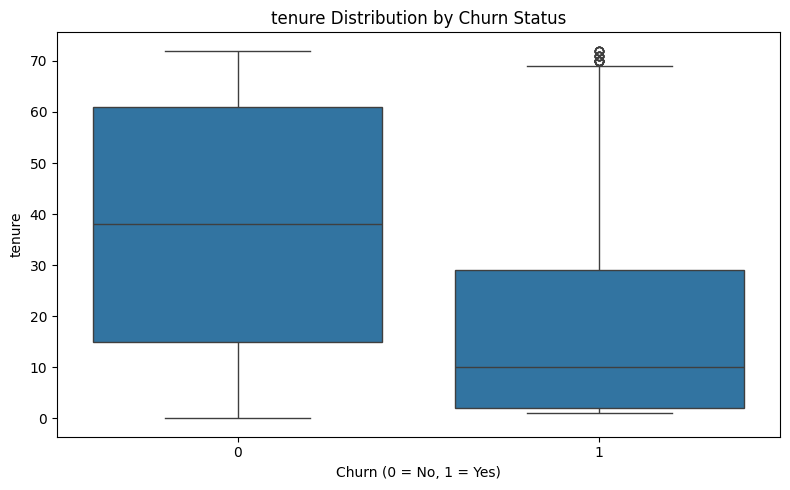

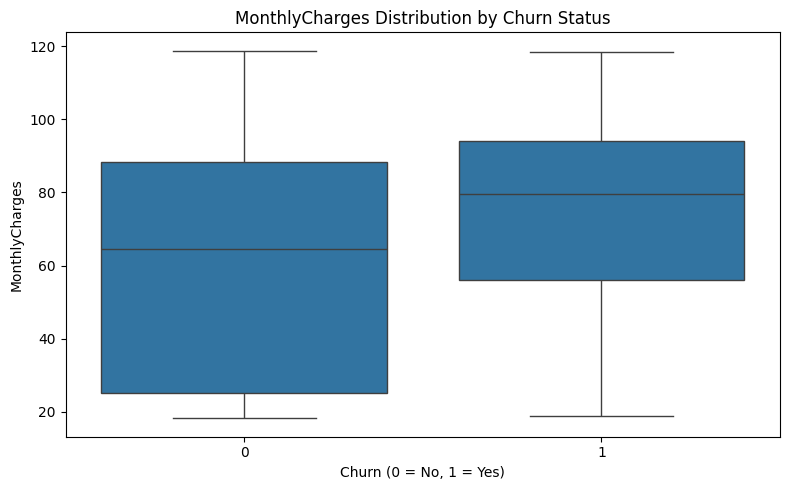

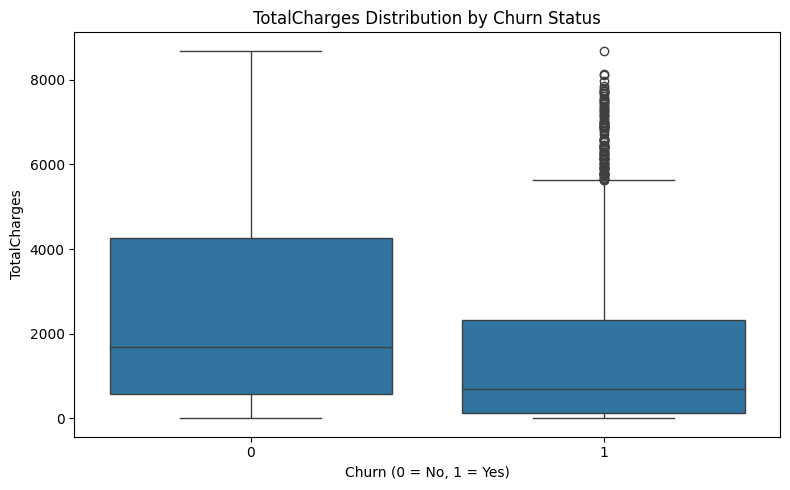

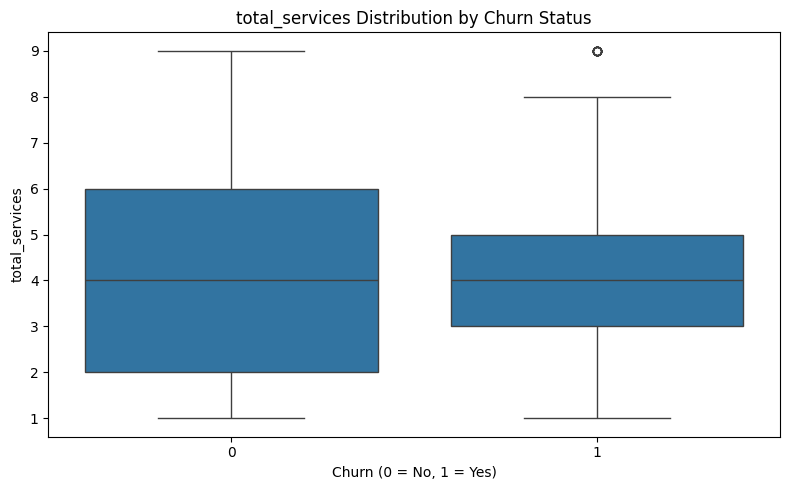

In [51]:
# Compare numerical feature distributions by churn status

for column in continuous_features:
    
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="Churn",
        y=column
    )
    
    plt.title(f"{column} Distribution by Churn Status")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.ylabel(column)
    
    plt.tight_layout()
    plt.show()

# 25. Feature Selection

Feature selection involves identifying variables that provide useful information for solving the customer churn prediction problem.

For this stage, correlation analysis will be used to examine relationships among numerical variables and identify potentially redundant features.

Categorical features will be retained because they may contain important information about customer behavior, services, contracts, and billing.

In [53]:
# Correlation matrix for numerical features

numerical_for_correlation = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "total_services",
    "Churn"
]

correlation_matrix = df[numerical_for_correlation].corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,total_services,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.118100,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,0.473803,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.851380,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,0.776431,-0.198324
total_services,0.118100,0.473803,0.851380,0.776431,1.000000,-0.019375
Churn,0.150889,-0.352229,0.193356,-0.198324,-0.019375,1.000000


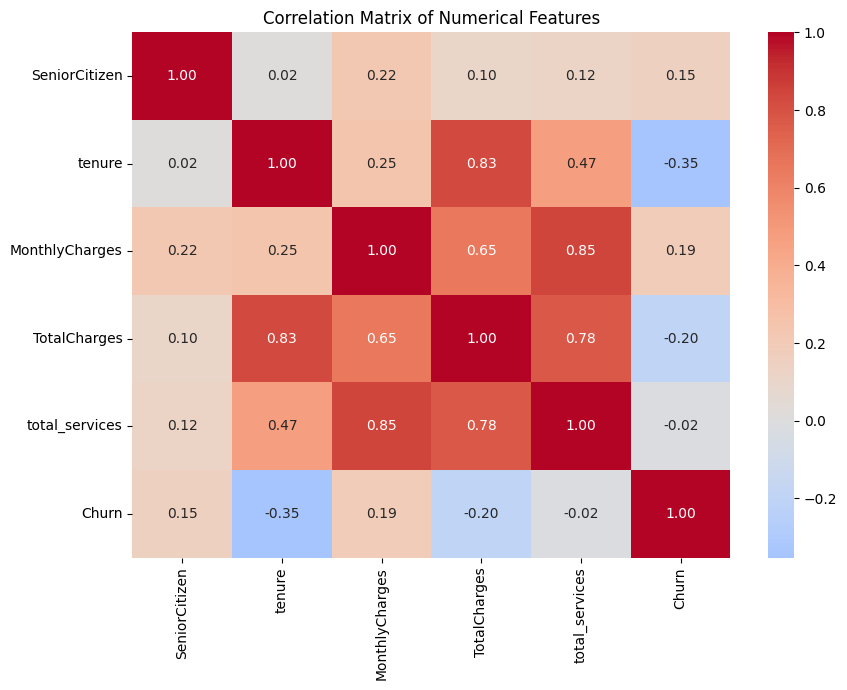

In [54]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

## 25.3 Feature Selection Observation

The correlation analysis provides an initial assessment of relationships between numerical variables and the churn target.

`tenure`, `MonthlyCharges`, and `TotalCharges` may show relationships with churn, while `SeniorCitizen` and `total_services` may have weaker or moderate relationships.

Correlation alone is not sufficient to determine whether a feature should be removed because machine learning models can identify nonlinear and categorical relationships that correlation does not capture.

Therefore, potentially useful features will be retained at this stage. More advanced feature importance analysis will be performed during model development in the following stage of the project.

# 26. Variance Analysis

Variance measures how much a feature varies across observations.

Features with almost no variation may provide little information to a machine learning model.

A variance check will therefore be performed before finalizing the feature set.

In [55]:
# Calculate variance for numerical features

variance_table = pd.DataFrame({
    "Feature": numerical_features,
    "Variance": [
        df[column].var()
        for column in numerical_features
    ]
})

variance_table.sort_values(
    by="Variance",
    ascending=True
)

,Feature,Variance
0,SeniorCitizen,1.358745e-01
4,total_services,5.348675e+00
1,tenure,6.031681e+02
2,MonthlyCharges,9.054109e+02
3,TotalCharges,5.138357e+06


# 27. Feature Selection Decision

Based on the data inspection, feature engineering, correlation analysis, and variance analysis:

- `customerID` was removed because it is an identifier.
- `Churn` is retained as the target variable.
- `tenure_group` is retained as an engineered categorical feature.
- `total_services` is retained as an engineered numerical feature.
- The remaining demographic, service, contract, and billing variables are retained because they may provide useful information for predicting customer churn.
- No feature is removed solely based on correlation because correlation does not capture all possible relationships between features and churn.

Feature selection may be refined further using model-based feature importance during the model development stage.

In [56]:
outlier_summary_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,tenure,9.00,55.00,46.00,-60.000,124.000,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.025,171.375,0,0.0
2,TotalCharges,398.55,3786.60,3388.05,-4683.525,8868.675,0,0.0
3,total_services,2.00,6.00,4.00,-4.000,12.000,0,0.0


# 28. Outlier Treatment Decision

The IQR analysis identified no statistical outliers in the continuous numerical features.

The results were:

- `tenure`: 0 potential outliers.
- `MonthlyCharges`: 0 potential outliers.
- `TotalCharges`: 0 potential outliers.
- `total_services`: 0 potential outliers.

Since no significant outliers were detected, no observations will be removed or capped based on the IQR method.

This decision preserves all 7,043 customer records and avoids unnecessarily removing legitimate customer information.

The numerical features will instead be standardized during the preprocessing pipeline.

In [57]:
correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,total_services,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.118100,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,0.473803,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.851380,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,0.776431,-0.198324
total_services,0.118100,0.473803,0.851380,0.776431,1.000000,-0.019375
Churn,0.150889,-0.352229,0.193356,-0.198324,-0.019375,1.000000


In [58]:
variance_table

,Feature,Variance
0,SeniorCitizen,1.358745e-01
1,tenure,6.031681e+02
2,MonthlyCharges,9.054109e+02
3,TotalCharges,5.138357e+06
4,total_services,5.348675e+00


# 29. Feature Selection Analysis

Feature selection was performed using correlation analysis and variance analysis.

The purpose was to identify features that may provide useful information for predicting customer churn and to identify features with little or no variation.

The analysis showed that several numerical features have meaningful relationships with the churn target, while some predictor variables are strongly correlated with one another.

In [59]:
# Correlation of numerical features with the target variable

churn_correlations = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

print("Correlation of numerical features with Churn:")
display(churn_correlations.to_frame(name="Correlation with Churn"))

Correlation of numerical features with Churn:


,Correlation with Churn
tenure,-0.352229
TotalCharges,-0.198324
MonthlyCharges,0.193356
SeniorCitizen,0.150889
total_services,-0.019375


### Observation

Among the numerical variables, `tenure` has the strongest linear relationship with the churn target, with a correlation of approximately -0.35.

This negative relationship suggests that customers with longer tenure tend to have lower churn rates.

`MonthlyCharges` has a positive correlation of approximately 0.19 with churn, suggesting that customers with higher monthly charges may have somewhat higher churn rates.

`TotalCharges` has a negative correlation of approximately -0.20, while `SeniorCitizen` has a positive correlation of approximately 0.15.

The engineered `total_services` feature has a very weak linear correlation with churn. However, it will be retained because correlation alone cannot determine whether a feature is useful to a machine learning model.

# 30. Multicollinearity Assessment

The correlation matrix also revealed strong relationships between several predictor variables.

Notable relationships include:

- `MonthlyCharges` and `total_services`: approximately 0.85
- `tenure` and `TotalCharges`: approximately 0.83
- `TotalCharges` and `total_services`: approximately 0.78

These relationships are expected to some extent because customers who subscribe to more services may have higher monthly charges, while customers with longer tenure have more accumulated charges.

These features will not be automatically removed at this stage because they represent different aspects of customer behavior.

However, multicollinearity will be monitored during model development. Tree-based models are generally less sensitive to multicollinearity than linear models.

# 31. Variance Analysis

Variance was examined to determine whether any numerical feature contains almost no variation across customers.

All numerical features demonstrate sufficient variation.

In particular, `SeniorCitizen`, despite having a relatively smaller variance than the continuous financial variables, is a binary demographic feature and still contains meaningful information.

Therefore, no numerical feature will be removed based on variance.

# 32. Final Feature Selection Decision

Based on the correlation and variance analysis, the following feature-selection decisions were made:

### Removed Feature

`customerID` was removed because it is a unique customer identifier and does not provide meaningful predictive information.

### Retained Numerical Features

The following numerical features will be retained:

- `SeniorCitizen`
- `tenure`
- `MonthlyCharges`
- `TotalCharges`
- `total_services`

Although some numerical features are strongly correlated, they represent different aspects of customer behavior and will therefore be retained for the initial machine learning pipeline.

### Retained Categorical Features

The categorical variables describing customer demographics, services, contracts, billing, and payment methods will also be retained because they may contain useful information for predicting churn.

### Target Variable

`Churn` is the target variable and has been encoded as:

- 0 = No churn
- 1 = Churn

No feature will be removed solely because of a weak correlation with churn. More advanced model-based feature importance can be performed during model development.

In [60]:
# ============================================================
# Final Feature Set
# ============================================================

final_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
    "tenure_group",
    "total_services"
]

print("Number of selected features:", len(final_features))

print("\nSelected features:")
for feature in final_features:
    print("-", feature)

Number of selected features: 21

Selected features:
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges
- tenure_group
- total_services


# 34. Prepare Features and Target

The final predictor variables will be separated from the target variable.

`X` contains the customer characteristics that will be used by the machine learning models.

`y` contains the target variable, `Churn`.

In [62]:
X = df[final_features].copy()
y = df["Churn"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7043, 21)
Target shape: (7043,)


# 35. Final Preprocessing Pipeline

The final preprocessing pipeline will transform the selected features into a numerical representation suitable for machine learning.

The following transformations will be applied:

### Numerical features
- Missing values → median imputation
- Scaling → StandardScaler

### Categorical features
- Missing values → most frequent category
- Encoding → One-Hot Encoding

The preprocessing operations will be fitted only on the training data to prevent data leakage.

In [63]:
# Identify numerical and categorical features from final feature set

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_services']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 21)
Testing set: (1409, 21)


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [66]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessing pipeline
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5634, 50)
Processed testing data shape: (1409, 50)


In [67]:
# Get the names of all transformed features

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 20 processed features:")
print(feature_names[:20])

Number of processed features: 50

First 20 processed features:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__total_services' 'cat__gender_Female'
 'cat__gender_Male' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No' 'cat__Dependents_Yes' 'cat__PhoneService_No'
 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No']


In [68]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Processed training dataframe:")
display(X_train_processed_df.head())

Processed training dataframe:


,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,num__total_services,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,cat__MultipleLines_No,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_No,cat__OnlineSecurity_No internet service,cat__OnlineSecurity_Yes,cat__OnlineBackup_No,cat__OnlineBackup_No internet service,cat__OnlineBackup_Yes,cat__DeviceProtection_No,cat__DeviceProtection_No internet service,cat__DeviceProtection_Yes,cat__TechSupport_No,cat__TechSupport_No internet service,cat__TechSupport_Yes,cat__StreamingTV_No,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,cat__tenure_group_Developing,cat__tenure_group_Established,cat__tenure_group_Long-term,cat__tenure_group_New
3738,-0.441773,0.102371,-0.521976,-0.262257,-0.072199,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3151,-0.441773,-0.711743,0.337478,-0.503635,-0.503095,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4860,-0.441773,-0.793155,-0.809013,-0.749883,-0.072199,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3867,-0.441773,-0.263980,0.284384,-0.172722,0.789595,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3810,-0.441773,-1.281624,-0.676279,-0.989374,-0.933992,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [69]:
X_train_processed_df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
num__SeniorCitizen,5634.0,7.440898e-17,1.000089,-0.441773,-0.441773,-0.441773,-0.441773,2.263606
num__tenure,5634.0,-1.008935e-17,1.000089,-1.322329,-0.955978,-0.141863,0.916486,1.608483
num__MonthlyCharges,5634.0,-2.402527e-16,1.000089,-1.544028,-0.971198,0.184834,0.831912,1.785939
num__TotalCharges,5634.0,2.522338e-17,1.000089,-1.008922,-0.832101,-0.396845,0.674194,2.801869
num__total_services,5634.0,-1.034159e-16,1.000089,-1.364889,-0.933992,-0.072199,0.789595,2.082285
cat__gender_Female,5634.0,4.971601e-01,0.500036,0.000000,0.000000,0.000000,1.000000,1.000000
cat__gender_Male,5634.0,5.028399e-01,0.500036,0.000000,0.000000,1.000000,1.000000,1.000000
cat__Partner_No,5634.0,5.156195e-01,0.499800,0.000000,0.000000,1.000000,1.000000,1.000000
cat__Partner_Yes,5634.0,4.843805e-01,0.499800,0.000000,0.000000,0.000000,1.000000,1.000000
cat__Dependents_No,5634.0,7.019879e-01,0.457425,0.000000,0.000000,1.000000,1.000000,1.000000


In [70]:
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)
print("Number of processed features:", len(feature_names))

Processed training data shape: (5634, 50)
Processed testing data shape: (1409, 50)
Number of processed features: 50


# 42. Verification of Preprocessed Data

The preprocessing pipeline successfully transformed the original dataset into a numerical machine-learning-ready representation.

The training dataset contains 5,634 observations and 50 processed features, while the testing dataset contains 1,409 observations and the same 50 processed features.

The increase from 21 selected input features to 50 processed features is primarily due to One-Hot Encoding of categorical variables.

The same preprocessing structure is applied to both training and testing data to ensure consistency.

In [71]:
print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)
print("Number of processed features:", len(feature_names))

print("\nMissing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Training data shape: (5634, 50)
Testing data shape: (1409, 50)
Number of processed features: 50

Missing values in processed training data: 0
Missing values in processed testing data: 0


# 43. Target Variable Verification

The target variable, `Churn`, was converted from categorical values into binary numerical values:

- `0` = Customer did not churn
- `1` = Customer churned

The target variable is kept separate from the preprocessing pipeline because it should not be scaled or one-hot encoded.

In [72]:
# Encode target variable

y_train_encoded = y_train.map({
    "No": 0,
    "Yes": 1
})

y_test_encoded = y_test.map({
    "No": 0,
    "Yes": 1
})

print("Training target distribution:")
print(y_train_encoded.value_counts())

print("\nTesting target distribution:")
print(y_test_encoded.value_counts())

Training target distribution:
Series([], Name: count, dtype: int64)

Testing target distribution:
Series([], Name: count, dtype: int64)


In [75]:
# Check missing values by column

missing_by_column = X_processed_df.isnull().sum()

print("Columns containing missing values:")
display(
    missing_by_column[missing_by_column > 0]
)

Columns containing missing values:


Churn    7043
dtype: int64

In [76]:
print("Original y values:")
print(y.unique())

print("\nOriginal y data type:")
print(y.dtype)

print("\nTarget counts:")
print(y.value_counts(dropna=False))

Original y values:
[0 1]

Original y data type:
int64

Target counts:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [77]:
# Create a clean binary target

if y.dtype == "object":
    y_final = y.map({
        "No": 0,
        "Yes": 1
    })
else:
    y_final = y.astype(int)

print(y_final.value_counts(dropna=False))

Churn
0    5174
1    1869
Name: count, dtype: int64


In [78]:
# Transform the complete feature dataset
X_processed = preprocessor.transform(X)

# Convert processed features to DataFrame
X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=X.index
)

# Add the correctly encoded target
X_processed_df["Churn"] = y_final.values

print("Final processed dataset shape:", X_processed_df.shape)

display(X_processed_df.head())

Final processed dataset shape: (7043, 51)


,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,num__total_services,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,cat__MultipleLines_No,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_No,cat__OnlineSecurity_No internet service,cat__OnlineSecurity_Yes,cat__OnlineBackup_No,cat__OnlineBackup_No internet service,cat__OnlineBackup_Yes,cat__DeviceProtection_No,cat__DeviceProtection_No internet service,cat__DeviceProtection_Yes,cat__TechSupport_No,cat__TechSupport_No internet service,cat__TechSupport_Yes,cat__StreamingTV_No,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,cat__tenure_group_Developing,cat__tenure_group_Established,cat__tenure_group_Long-term,cat__tenure_group_New,Churn
0,-0.441773,-1.281624,-1.164077,-0.995824,-0.933992,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,-0.441773,0.061666,-0.264803,-0.179831,-0.072199,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
2,-0.441773,-1.240918,-0.367672,-0.961467,-0.072199,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
3,-0.441773,0.509429,-0.750942,-0.201222,-0.072199,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,-0.441773,-1.240918,0.191470,-0.942379,-0.933992,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1


In [79]:
print("Rows:", X_processed_df.shape[0])
print("Columns:", X_processed_df.shape[1])

print("\nMissing values:",
      X_processed_df.isnull().sum().sum())

print("\nDuplicate rows:",
      X_processed_df.duplicated().sum())

Rows: 7043
Columns: 51

Missing values: 0

Duplicate rows: 22


# Duplicate Records After Preprocessing

The original dataset contained 0 duplicate records.

After removing the unique `customerID` identifier and applying feature transformations, 22 duplicate feature representations were identified in the processed dataset.

These records do not necessarily represent duplicate customers. Different customers can have identical demographic, service, billing, and tenure characteristics.

Therefore, these 22 processed duplicate representations were retained because removing them could incorrectly discard legitimate customer observations.

The original dataset-level duplicate assessment remains the basis for duplicate-record cleaning.

In [80]:
# ============================================================
# FINAL DATA QUALITY CHECK
# ============================================================

print("===== FINAL DATA QUALITY CHECK =====")

print("Rows:", X_processed_df.shape[0])
print("Columns:", X_processed_df.shape[1])

print(
    "Missing values:",
    X_processed_df.isnull().sum().sum()
)

print(
    "Duplicate processed rows:",
    X_processed_df.duplicated().sum()
)

print(
    "Infinite values:",
    np.isinf(
        X_processed_df.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nTarget distribution:")
print(X_processed_df["Churn"].value_counts())

print("\nTarget proportions:")
print(
    X_processed_df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

===== FINAL DATA QUALITY CHECK =====
Rows: 7043
Columns: 51
Missing values: 0
Duplicate processed rows: 22
Infinite values: 0

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target proportions:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [81]:
import os

os.makedirs("data/processed", exist_ok=True)

processed_path = "data/processed/processed_telco_churn.csv"

X_processed_df.to_csv(
    processed_path,
    index=False
)

print("Processed dataset saved successfully.")
print("Location:", processed_path)

Processed dataset saved successfully.
Location: data/processed/processed_telco_churn.csv


In [82]:
import os

print(
    "File exists:",
    os.path.exists(processed_path)
)

print(
    "File size:",
    round(os.path.getsize(processed_path) / 1024, 2),
    "KB"
)

File exists: True
File size: 1934.38 KB
